# Experiment 3: Concept Drift Detection

## Aim

To generate a dataset, train a Logistic Regression model on it, then change the target rule
(concept drift), evaluate the old model on the new data, and compare the accuracy before and
after the drift.

## Theory

Concept drift occurs when the statistical relationship between the input features and the target
variable changes over time. A model trained on old data assumes the old relationship still holds.
When the relationship changes, the model keeps making predictions using an outdated pattern and
its accuracy falls. Detecting this drop in accuracy is the simplest way to detect concept drift.

## Requirements

- Python 3.x
- Jupyter Notebook
- NumPy
- Pandas
- Matplotlib
- Scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [3]:
np.random.seed(42)

n_samples = 1000

X1 = np.random.randn(n_samples, 2)
y1 = (X1[:, 0] + X1[:, 1] > 0).astype(int)

print("Shape of X1 :", X1.shape)
print("Shape of y1 :", y1.shape)

Shape of X1 : (1000, 2)
Shape of y1 : (1000,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X1,
    y1,
    test_size=0.3,
    random_state=42
)

print("Training samples :", len(X_train))
print("Testing samples  :", len(X_test))

Training samples : 700
Testing samples  : 300


In [5]:
model = LogisticRegression()

model.fit(X_train, y_train)

/Users/rohithkumar/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/rohithkumar/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/rohithkumar/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


LogisticRegression()

In [6]:
y_pred = model.predict(X_test)

acc_before = accuracy_score(y_test, y_pred)

print("Accuracy before drift :", acc_before)

Accuracy before drift : 0.9933333333333333


In [7]:
X2 = np.random.randn(n_samples, 2)
y2 = ((X2[:, 0] - X2[:, 1]) > 0).astype(int)

print("New target rule : y = (x1 - x2 > 0)")

New target rule : y = (x1 - x2 > 0)


In [8]:
y_drift_pred = model.predict(X2)

acc_after = accuracy_score(y2, y_drift_pred)

print("Accuracy after drift :", acc_after)

Accuracy after drift : 0.519


/Users/rohithkumar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rohithkumar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rohithkumar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [9]:
print("Performance Comparison")
print("Before drift :", round(acc_before, 2))
print("After drift  :", round(acc_after, 2))

Performance Comparison
Before drift : 0.99
After drift  : 0.52


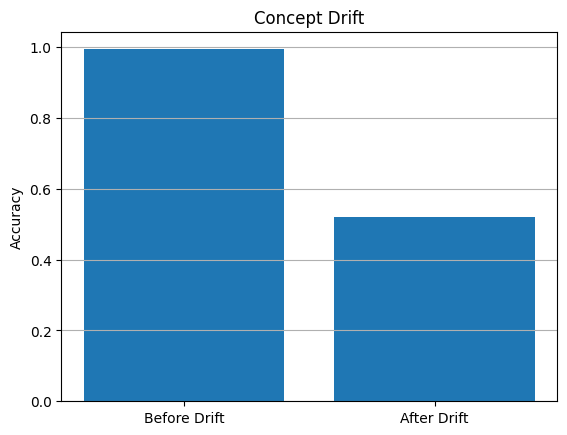

In [10]:
plt.figure()

plt.bar(["Before Drift", "After Drift"], [acc_before, acc_after])

plt.ylabel("Accuracy")
plt.title("Concept Drift")
plt.grid(True, axis="y")

plt.show()

## Interpretation

- 1000 samples are generated.
- The target depends on y = (x1 + x2 > 0).
- This rule represents the original concept or relationship in the data.
- The model will learn this pattern.
- 70% of the data is used for training.
- 30% is used for testing.
- This split lets us evaluate model performance on unseen data.
- Logistic Regression learns the relationship in the data.
- The model is trained on data before drift occurs.
- Predictions are made on the original test data.
- Accuracy is expected to be high because training and testing data follow the same concept.
- A new dataset is then generated.
- The target rule changes to y = (x1 - x2 > 0).
- This change is called concept drift.
- The old model is evaluated on the new data.
- Since the pattern changed, accuracy usually drops.
- If accuracy drops significantly, concept drift has occurred.
- A lower second bar in the chart visually confirms concept drift.

## Result

Concept drift was successfully demonstrated. The model achieved high accuracy on data following
the original concept and a much lower accuracy after the target rule changed, confirming that
concept drift degrades model performance.